### yfinance meaning Yahoo finance

In [1]:
import yfinance as yf

In [2]:
sp500 = yf.Ticker("RELIANCE.NS")

In [3]:
sp500 = sp500.history(period= "max")

In [4]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1996-01-01 00:00:00+05:30,3.628409,3.647878,3.604514,3.641683,104121369,0.0,0.0
1996-01-02 00:00:00+05:30,3.632835,3.650534,3.586816,3.613365,168743308,0.0,0.0
1996-01-03 00:00:00+05:30,3.672659,3.839920,3.632835,3.640800,209323879,0.0,0.0
1996-01-04 00:00:00+05:30,3.606284,3.617789,3.558495,3.607169,216900264,0.0,0.0
1996-01-05 00:00:00+05:30,3.593010,3.593010,3.551416,3.582391,166708467,0.0,0.0
...,...,...,...,...,...,...,...
2025-03-28 00:00:00+05:30,1280.000000,1295.750000,1269.000000,1275.099976,18147129,0.0,0.0
2025-04-01 00:00:00+05:30,1264.599976,1277.900024,1249.300049,1252.599976,12099648,0.0,0.0
2025-04-02 00:00:00+05:30,1247.550049,1255.550049,1243.900024,1251.150024,10142590,0.0,0.0


In [5]:
sp500.index = sp500.index.date


In [6]:
import pandas as pd


In [7]:
sp500.index = pd.to_datetime(sp500.index).normalize()

In [8]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
1996-01-01,3.628409,3.647878,3.604514,3.641683,104121369,0.0,0.0
1996-01-02,3.632835,3.650534,3.586816,3.613365,168743308,0.0,0.0
1996-01-03,3.672659,3.839920,3.632835,3.640800,209323879,0.0,0.0
1996-01-04,3.606284,3.617789,3.558495,3.607169,216900264,0.0,0.0
1996-01-05,3.593010,3.593010,3.551416,3.582391,166708467,0.0,0.0
...,...,...,...,...,...,...,...
2025-03-28,1280.000000,1295.750000,1269.000000,1275.099976,18147129,0.0,0.0
2025-04-01,1264.599976,1277.900024,1249.300049,1252.599976,12099648,0.0,0.0
2025-04-02,1247.550049,1255.550049,1243.900024,1251.150024,10142590,0.0,0.0
2025-04-03,1233.050049,1251.800049,1233.050049,1248.699951,7434366,0.0,0.0


In [9]:
sp500.index

DatetimeIndex(['1996-01-01', '1996-01-02', '1996-01-03', '1996-01-04',
               '1996-01-05', '1996-01-08', '1996-01-09', '1996-01-10',
               '1996-01-11', '1996-01-12',
               ...
               '2025-03-21', '2025-03-24', '2025-03-25', '2025-03-26',
               '2025-03-27', '2025-03-28', '2025-04-01', '2025-04-02',
               '2025-04-03', '2025-04-04'],
              dtype='datetime64[ns]', length=7347, freq=None)

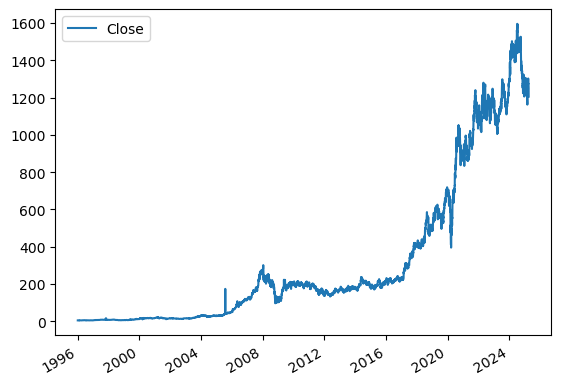

In [10]:
sp500.plot.line(y = "Close", use_index = "True");

In [11]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [12]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [13]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
1996-01-01,3.628409,3.647878,3.604514,3.641683,104121369,3.613365
1996-01-02,3.632835,3.650534,3.586816,3.613365,168743308,3.640800
1996-01-03,3.672659,3.839920,3.632835,3.640800,209323879,3.607169
1996-01-04,3.606284,3.617789,3.558495,3.607169,216900264,3.582391
1996-01-05,3.593010,3.593010,3.551416,3.582391,166708467,3.439023
...,...,...,...,...,...,...
2025-03-28,1280.000000,1295.750000,1269.000000,1275.099976,18147129,1252.599976
2025-04-01,1264.599976,1277.900024,1249.300049,1252.599976,12099648,1251.150024
2025-04-02,1247.550049,1255.550049,1243.900024,1251.150024,10142590,1248.699951
2025-04-03,1233.050049,1251.800049,1233.050049,1248.699951,7434366,1204.699951


In [14]:
sp500["Target"] = (sp500["Tomorrow"]> sp500["Close"]).astype(int)
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
1996-01-01,3.628409,3.647878,3.604514,3.641683,104121369,3.613365,0
1996-01-02,3.632835,3.650534,3.586816,3.613365,168743308,3.640800,1
1996-01-03,3.672659,3.839920,3.632835,3.640800,209323879,3.607169,0
1996-01-04,3.606284,3.617789,3.558495,3.607169,216900264,3.582391,0
1996-01-05,3.593010,3.593010,3.551416,3.582391,166708467,3.439023,0
...,...,...,...,...,...,...,...
2025-03-28,1280.000000,1295.750000,1269.000000,1275.099976,18147129,1252.599976,0
2025-04-01,1264.599976,1277.900024,1249.300049,1252.599976,12099648,1251.150024,0
2025-04-02,1247.550049,1255.550049,1243.900024,1251.150024,10142590,1248.699951,0
2025-04-03,1233.050049,1251.800049,1233.050049,1248.699951,7434366,1204.699951,0


In [15]:
sp500 = sp500.loc["1996-01-01":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
1996-01-01,3.628409,3.647878,3.604514,3.641683,104121369,3.613365,0
1996-01-02,3.632835,3.650534,3.586816,3.613365,168743308,3.640800,1
1996-01-03,3.672659,3.839920,3.632835,3.640800,209323879,3.607169,0
1996-01-04,3.606284,3.617789,3.558495,3.607169,216900264,3.582391,0
1996-01-05,3.593010,3.593010,3.551416,3.582391,166708467,3.439023,0
...,...,...,...,...,...,...,...
2025-03-28,1280.000000,1295.750000,1269.000000,1275.099976,18147129,1252.599976,0
2025-04-01,1264.599976,1277.900024,1249.300049,1252.599976,12099648,1251.150024,0
2025-04-02,1247.550049,1255.550049,1243.900024,1251.150024,10142590,1248.699951,0
2025-04-03,1233.050049,1251.800049,1233.050049,1248.699951,7434366,1204.699951,0


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators =100, min_samples_split = 100, random_state = 1)
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [17]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0])

In [18]:
preds = pd.Series(preds, index =test.index)

In [19]:
preds

2024-11-11    0
2024-11-12    0
2024-11-13    0
2024-11-14    0
2024-11-18    0
             ..
2025-03-28    0
2025-04-01    0
2025-04-02    1
2025-04-03    0
2025-04-04    0
Length: 100, dtype: int32

In [20]:
precision_score(test["Target"], preds)

0.46

In [21]:
combined = pd.concat([test["Target"], preds], axis =1)
combined

,Target,0
2024-11-11,1,0
2024-11-12,0,0
2024-11-13,1,0
2024-11-14,0,0
2024-11-18,0,0
...,...,...
2025-03-28,0,0
2025-04-01,0,0
2025-04-02,0,1
2025-04-03,0,0


<Axes: >

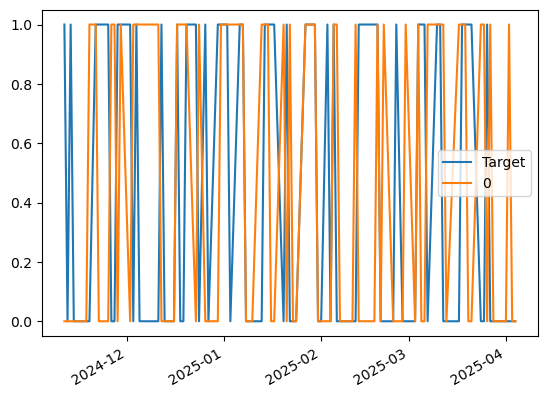

In [22]:
combined.plot()

In [23]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index =test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined


In [24]:
def backtest(data, model, predictors, start= 2500, step =250):
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)  

In [25]:
predictions = backtest(sp500, model, predictors)


In [26]:
predictions["Predictions"].value_counts()

0    2827
1    2020
Name: Predictions, dtype: int64

In [27]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5044554455445545

In [28]:
predictions["Target"].value_counts()/predictions.shape[0]

1    0.514132
0    0.485868
Name: Target, dtype: float64

In [29]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_avg = sp500.rolling(horizon).mean()
    
    ratio_col = f"Close_Ratio_{horizon}"
    sp500[ratio_col] = sp500["Close"]/ rolling_avg["Close"]
    
    trend_col = f"Trend_{horizon}"
    sp500[trend_col] = sp500.shift(1).rolling(horizon).sum()["Target"]
    
    new_predictors += [ratio_col, trend_col]

In [30]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
1996-01-01,3.628409,3.647878,3.604514,3.641683,104121369,3.613365,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-01-02,3.632835,3.650534,3.586816,3.613365,168743308,3.640800,1,0.996097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-01-03,3.672659,3.839920,3.632835,3.640800,209323879,3.607169,0,1.003782,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-01-04,3.606284,3.617789,3.558495,3.607169,216900264,3.582391,0,0.995360,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-01-05,3.593010,3.593010,3.551416,3.582391,166708467,3.439023,0,0.996554,0.0,0.990409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-28,1280.000000,1295.750000,1269.000000,1275.099976,18147129,1252.599976,0,0.998786,1.0,0.994013,2.0,1.023853,30.0,0.925539,126.0,1.064822,520.0
2025-04-01,1264.599976,1277.900024,1249.300049,1252.599976,12099648,1251.150024,0,0.991099,0.0,0.984068,1.0,1.005767,29.0,0.909829,125.0,1.045772,520.0
2025-04-02,1247.550049,1255.550049,1243.900024,1251.150024,10142590,1248.699951,0,0.999421,0.0,0.988255,1.0,1.004157,29.0,0.909382,125.0,1.044298,520.0
2025-04-03,1233.050049,1251.800049,1233.050049,1248.699951,7434366,1204.699951,0,0.999020,0.0,0.990128,1.0,1.002086,28.0,0.908212,125.0,1.041976,520.0


In [31]:
sp500 = sp500.dropna()

In [32]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
1999-11-01,10.702688,10.743660,9.862771,9.917399,114373142,10.666268,1,0.961174,0.0,0.905069,0.0,1.042669,27.0,1.404989,116.0,1.687540,458.0
1999-11-02,9.787655,10.711792,9.673845,10.666268,129022957,10.263382,0,1.036382,1.0,0.990782,1.0,1.115980,28.0,1.506248,116.0,1.812791,459.0
1999-11-03,10.943965,10.943965,10.119982,10.263382,175844467,10.292972,1,0.980750,1.0,0.974708,1.0,1.069273,28.0,1.445104,115.0,1.742357,458.0
1999-11-04,10.190543,10.491000,10.065351,10.292972,122838876,10.584323,1,1.001439,1.0,0.992407,2.0,1.067559,29.0,1.444939,116.0,1.745400,459.0
1999-11-05,10.288417,10.734553,10.288417,10.584323,131084769,10.584323,0,1.013955,2.0,1.023147,3.0,1.092181,30.0,1.481176,116.0,1.792676,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-27,1278.150024,1285.000000,1271.300049,1278.199951,15028056,1275.099976,0,1.002019,1.0,0.996235,3.0,1.026800,31.0,0.927354,126.0,1.067686,520.0
2025-03-28,1280.000000,1295.750000,1269.000000,1275.099976,18147129,1252.599976,0,0.998786,1.0,0.994013,2.0,1.023853,30.0,0.925539,126.0,1.064822,520.0
2025-04-01,1264.599976,1277.900024,1249.300049,1252.599976,12099648,1251.150024,0,0.991099,0.0,0.984068,1.0,1.005767,29.0,0.909829,125.0,1.045772,520.0
2025-04-02,1247.550049,1255.550049,1243.900024,1251.150024,10142590,1248.699951,0,0.999421,0.0,0.988255,1.0,1.004157,29.0,0.909382,125.0,1.044298,520.0


In [33]:
model = RandomForestClassifier(n_estimators = 200, min_samples_split =50 , random_state = 1)

In [34]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >= 0.6] = 1
    preds[preds < 0.6] = 0
    preds = pd.Series(preds, index =test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined


In [35]:
predictions = backtest(sp500, model, new_predictors)

In [36]:
predictions["Predictions"].value_counts()

0.0    3503
1.0     343
Name: Predictions, dtype: int64

In [37]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5306122448979592